# Clinico-Transcriptomic Discovery of Prognostic Biomarkers and Functional Hallmarks in TCGA Breast Cancer Using Python
---
   ## Notebook 6: Clinico-Genomic Machine Learning for Five-Year Survival Prediction

### 1. Biological Motivation

Following differential expression analysis, survival modelling, and biomarker prioritization, the final stage of the analytical workflow investigated whether the identified biomarkers could be integrated into a supervised machine learning framework for individualized prognosis. Whereas the Cox proportional hazards model estimates the relative hazard of death while explicitly accounting for time-to-event information, machine learning classifiers instead attempt to predict discrete patient outcomes from multidimensional feature sets. This complementary approach evaluates whether transcriptomic biomarkers, when combined with treatment information, possess sufficient predictive power to classify patients according to long-term survival status.

To achieve this objective, a Random Forest classifier was constructed using the five candidate biomarkers identified throughout the preceding analyses together with major treatment variables. Model performance was subsequently assessed using independent validation data to determine both predictive accuracy and the relative contribution of genomic versus clinical variables to outcome prediction.


### 2. Import Required Libraries

In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split

### 3. Load Clino-Genomic Matrix

In [2]:
counts_log = pd.read_csv("../data/processed/brca_counts_normalized_log.csv", index_col=0)
clinical = pd.read_csv("../data/processed/brca_clinical_cleaned.csv", index_col=0)
dgea_results = pd.read_csv("../results/tables/brca_dgea_master_results.csv")

### 4. Annotate the Expression Matrix with Gene Symbols

In [3]:
genes_of_interest = ["PLK1", "MAD2L1", "TRIM67", "NOS1", "ALB"]

if "gene_id" in dgea_results.columns:
    dgea_lookup = dgea_results.set_index("gene_id")
else:
    dgea_lookup = dgea_results.copy()

counts_log_named = counts_log.merge(dgea_lookup[["gene_name"]], left_index=True, right_index=True, how="inner")
counts_log_named = counts_log_named.drop_duplicates(subset=["gene_name"]).set_index("gene_name")
target_expr = counts_log_named.loc[genes_of_interest].T

### 5. Construction of the Clinico-Genomic Feature Matrix

In [4]:
treatment_cols = ["had_surgery", "had_chemo", "had_radiation"]

ml_matrix = target_expr.merge(
    clinical[["time", "event"] + treatment_cols], 
    left_index=True, 
    right_index=True, 
    how="inner"
)

for col in treatment_cols:
    ml_matrix[col] = ml_matrix[col].astype(int)

### 6. Engineering the Five-Year Survival Outcome

In [5]:
five_years = 1825

def label_target(row):
    if row["time"] <= five_years and row["event"] == 1:
        return 1  
    elif row["time"] > five_years:
        return 0  
    else:
        return np.nan  

ml_matrix["target_5yr"] = ml_matrix.apply(label_target, axis=1)
ml_matrix = ml_matrix.dropna(subset=["target_5yr"])

### 7. Define Features (X) and Target (y)

In [6]:
feature_cols = genes_of_interest + treatment_cols
X = ml_matrix[feature_cols]
y = ml_matrix["target_5yr"].astype(int)

print(f"Machine Learning Framework Compiled Successfully.")
print(f"Total verified samples: {X.shape[0]}")
print(f"Class Distribution: Survived past 5yrs (0): {sum(y==0)} | Deceased within 5yrs (1): {sum(y==1)}\n")

Machine Learning Framework Compiled Successfully.
Total verified samples: 336
Class Distribution: Survived past 5yrs (0): 237 | Deceased within 5yrs (1): 99



### 8. Train-Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

### 9. Train Random Forest Classifier

A **Random Forest classifier** consisting of 100 decision trees was trained using the training data. To mitigate bias introduced by the imbalanced outcome distribution, the classifier employed balanced class weighting, thereby increasing the contribution of minority-class observations during model optimization.

Input variables included:

* Expression of PLK1
* Expression of MAD2L1
* Expression of TRIM67
* Expression of NOS1
* Expression of ALB
* Surgery status
* Chemotherapy status
* Radiotherapy status

Model predictions on the independent testing cohort were subsequently evaluated using standard classification metrics, including the confusion matrix, precision, recall, F1-score, and receiver operating characteristic (ROC) analysis.


In [8]:
rf_model = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]

print("--- Classification Report (Test Set) ---")
print(classification_report(y_test, y_pred, target_names=["Survived >5Y", "Deceased <=5Y"]))

--- Classification Report (Test Set) ---
               precision    recall  f1-score   support

 Survived >5Y       0.71      0.81      0.76        48
Deceased <=5Y       0.31      0.20      0.24        20

     accuracy                           0.63        68
    macro avg       0.51      0.51      0.50        68
 weighted avg       0.59      0.63      0.61        68



### 10. Visualize Classification Performance Metrics

- Plot 1: Confusion Matrix
- Plot 2: ROC-AUC Curve

C:\Users\Nonye\anaconda3\envs\rnaseq_env\lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


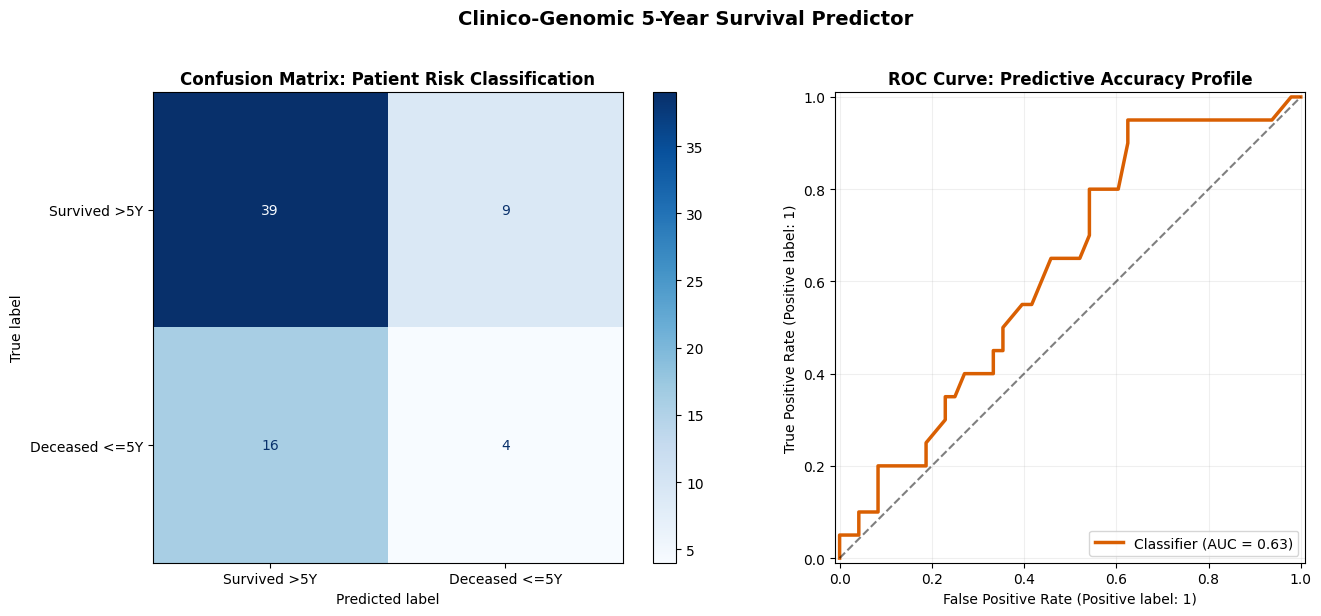

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["Survived >5Y", "Deceased <=5Y"], cmap="Blues", ax=ax[0]
)
ax[0].set_title("Confusion Matrix: Patient Risk Classification", fontweight="bold")

# Plot 2: ROC-AUC Curve
RocCurveDisplay.from_predictions(y_test, y_proba, ax=ax[1], color="#d95f02", linewidth=2.5)
ax[1].plot([0, 1], [0, 1], "k--", alpha=0.5)  
ax[1].set_title("ROC Curve: Predictive Accuracy Profile", fontweight="bold")
ax[1].grid(alpha=0.2)


plt.suptitle("Clinico-Genomic 5-Year Survival Predictor", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../results/figures/ml_plots/rf_survival_validation.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation:
**Classification Performance**

Evaluation on the independent testing dataset produced an overall classification accuracy of 63%.

Performance differed substantially between the two outcome classes.

The classifier identified long-term survivors considerably more effectively than patients who died within five years. Specifically, survivor classification achieved a precision of 71%, with a recall of 81%, indicating that the majority of true long-term survivors were correctly recognized by the model.

Conversely, prediction of early mortality proved substantially more challenging. The classifier achieved a precision of 31% and a recall of 20%, correctly identifying only four of the twenty deceased patients within the testing cohort while misclassifying the remaining sixteen as survivors.

This asymmetry reflects a common consequence of class imbalance, whereby machine learning algorithms preferentially learn the characteristics of the majority class despite balanced weighting. Although class weighting partially compensates for unequal sample sizes, the comparatively limited number of deceased patients restricted the model's ability to learn sufficiently discriminative patterns associated with poor prognosis.

Receiver operating characteristic analysis produced an area under the curve (AUC) of approximately 0.63, indicating that the integrated clinico-genomic model performed consistently better than random classification (AUC = 0.50), while remaining substantially below the discrimination achieved by the Cox proportional hazards model developed in the previous notebook.

### 11. Extract Feeature Importance

In [10]:
importances = rf_model.feature_importances_
importance_df = pd.DataFrame({"Feature": feature_cols, "Importance": importances})
importance_df = importance_df.sort_values(by="Importance", ascending=False)

print("\n--- Model Feature Importance Ranking ---")
print(importance_df.to_string(index=False))


--- Model Feature Importance Ranking ---
      Feature  Importance
         PLK1    0.187799
       TRIM67    0.182765
          ALB    0.179282
       MAD2L1    0.163773
         NOS1    0.137491
had_radiation    0.090132
    had_chemo    0.038100
  had_surgery    0.020657


#### Interpretation:
**Feature Importance Analysis**

One of the principal strengths of Random Forest models is their ability to estimate the relative contribution of each predictor to classification decisions. Feature importance analysis demonstrated that genomic biomarkers overwhelmingly dominated model performance.

The variables ranked in descending order of importance were:

| Rank | Feature      | Importance |
| ---: | ------------ | ---------: |
|    1 | PLK1         |      0.188 |
|    2 | TRIM67       |      0.183 |
|    3 | ALB          |      0.179 |
|    4 | MAD2L1       |      0.164 |
|    5 | NOS1         |      0.137 |
|    6 | Radiotherapy |      0.090 |
|    7 | Chemotherapy |      0.038 |
|    8 | Surgery      |      0.021 |

Collectively, the five transcriptomic biomarkers contributed approximately **85% of the total predictive importance**, whereas the three treatment variables accounted for only approximately **15%**.

This finding provides strong independent validation of the earlier biomarker discovery pipeline. Across differential expression analysis, survival modelling, and machine learning, the selected genes consistently emerged as the principal determinants of patient stratification.

Interestingly, this importance ranking contrasts with the multivariable Cox regression results, where treatment variables exerted stronger effects on hazard estimation. This apparent discrepancy reflects fundamental methodological differences between the two modelling approaches.

Cox regression evaluates how covariates influence the instantaneous hazard over continuous follow-up time, whereas Random Forests construct nonlinear decision boundaries based on the statistical variability of predictor values. Continuous gene expression measurements therefore provide substantially richer partitioning information for decision trees than binary treatment indicators, explaining their dominant contribution within the machine learning framework.


### Notebook Summary

Although the classifier demonstrated only moderate predictive performance, these findings provide important methodological insights into prognostic modelling of breast cancer.

> First, transforming continuous survival outcomes into a binary five-year endpoint inevitably reduces information content. Patients dying immediately before and immediately after the five-year threshold possess biologically similar disease trajectories but are assigned opposite outcome classes. This artificial dichotomization introduces classification noise that cannot be captured by conventional binary algorithms. Consequently, the superior performance of the Cox proportional hazards model observed previously supports the conclusion that time-to-event modelling remains fundamentally more appropriate for survival prediction in oncology.

> Second, although the selected biomarkers consistently exhibited strong predictive importance, five genes alone are unlikely to capture the full biological complexity underlying long-term breast cancer outcomes. Disease progression reflects the combined influence of genomic alterations, epigenetic regulation, tumour microenvironment, molecular subtype, treatment response, and host-specific factors. Future predictive models would therefore be expected to benefit from incorporation of additional multi-omic information, including DNA methylation, copy number variation, somatic mutation burden, tumour stage, and molecular subtype annotations.

> Finally, despite its moderate discrimination, the model demonstrated relatively high precision when identifying long-term survivors. Approximately seven out of every ten patients predicted to survive beyond five years were correctly classified. Within a clinical context, such predictive capability may ultimately assist in identifying lower-risk patients who could benefit from less intensive treatment strategies, thereby reducing unnecessary treatment-related toxicity while preserving favourable outcomes.

This notebook demonstrates the feasibility of integrating transcriptomic biomarkers with clinical treatment variables to construct a machine learning model for individualized breast cancer prognosis. Although predictive accuracy was constrained by class imbalance and the inherent limitations of binary survival classification, feature importance analysis confirmed that the candidate biomarkers identified throughout the analytical pipeline contributed substantially more predictive information than treatment variables alone.

Importantly, the comparison between Random Forest classification and Cox proportional hazards regression highlights a key methodological conclusion of this study: survival analysis methods that explicitly model time-to-event information provide superior prognostic performance for breast cancer datasets, whereas machine learning classifiers offer complementary insights into nonlinear feature interactions and biomarker importance. Together, these approaches provide a comprehensive framework for biomarker evaluation, prognostic modelling, and translational interpretation within precision oncology.